<a href="https://colab.research.google.com/github/Grupo-LCE0212/Estatistica/blob/main/tarefa06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Tarefa 06 - Estastística

Nome: Iago Aparecido Dias dos Santos N​​° USP:16873011

Nome: João Pedro Paschoalini N​​° USP:17831089

Nome: Maria Eduarda Porta N° USP: 17074105

# Conjunto de dados

O conjunto de dados utilizado contém informações sobre diferentes alimentos e apresenta duas variáveis numéricas relacionadas à sua composição nutricional: o **teor de gordura** e o **valor energético**.

O teor de gordura é expresso em **gramas de gordura a cada 100 gramas de alimento (g/100 g)** e representa a quantidade de gordura presente em cada alimento. Já o valor energético é expresso em **quilocalorias a cada 100 gramas de alimento (kcal/100 g)** e indica a quantidade de energia fornecida pelo alimento.

Nesta análise, o teor de gordura será considerado a variável **X**, enquanto o valor energético será considerado a variável **Y**. O objetivo é observar se existe uma relação linear entre a quantidade de gordura presente nos alimentos e seu valor energético.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Import the Excel file
df = pd.read_excel('/content/dados_regressao_alimentos.xlsx')

# Display the first few rows of the DataFrame to verify import
print("Primeiras 5 linhas do DataFrame:")
display(df.head())


Primeiras 5 linhas do DataFrame:


,Alimento,Gordura (g/100 g),Energia (kcal/100 g)
0,Leite integral,3.2,61
1,Iogurte natural,3.0,63
2,Ovo,9.5,143
3,Queijo muçarela,22.0,300
4,Carne bovina,15.0,250


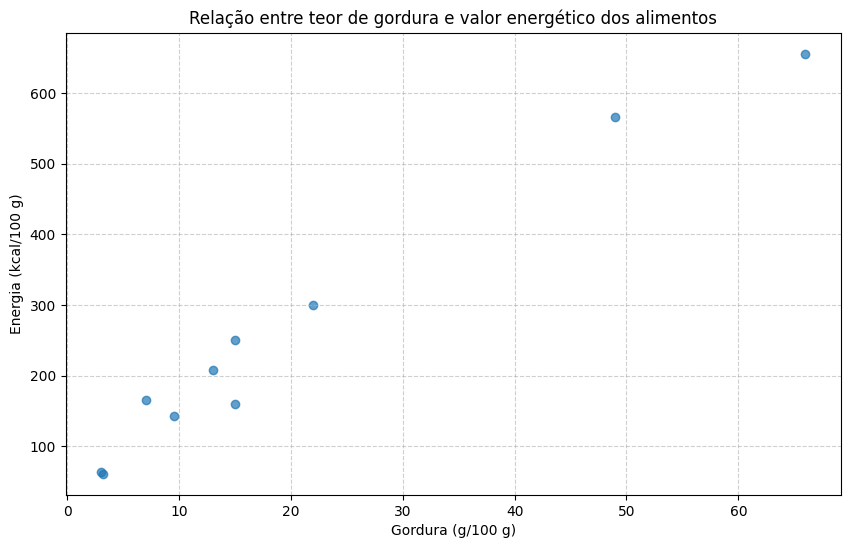

In [5]:
# Construct a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Gordura (g/100 g)'], df['Energia (kcal/100 g)'], alpha=0.7)

# Add title and labels
plt.title('Relação entre teor de gordura e valor energético dos alimentos')
plt.xlabel('Gordura (g/100 g)')
plt.ylabel('Energia (kcal/100 g)')

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()


# Regressão linear simples

A regressão é uma técnica estatística utilizada para analisar a relação entre duas variáveis numéricas. Ela busca ajustar uma reta aos dados para representar como uma variável tende a se comportar quando a outra varia.

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare the data for regression
X = df['Gordura (g/100 g)'].values.reshape(-1, 1) # X must be 2D
Y = df['Energia (kcal/100 g)'].values

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, Y)

# Get the coefficients
b0 = model.intercept_
b1 = model.coef_[0]

# Print the results
print(f"Intercepto (b_0): {b0:.2f}")
print(f"Coeficiente angular (b_1): {b1:.2f}")
print(f"\nEquação estimada da reta: Ŷ = {b0:.2f} + {b1:.2f}X")


Intercepto (b_0): 64.04
Coeficiente angular (b_1): 9.53

Equação estimada da reta: Ŷ = 64.04 + 9.53X


### Interpretação dos Coeficientes da Regressão

- **Intercepto (64,04):** O valor de `64,04` representa o valor estimado da energia (Y) quando a gordura (X) é zero. No contexto dos nossos dados, seria a energia que um alimento teria se não contivesse gordura. É importante notar que nem sempre faz sentido físico ter zero gordura, então este valor pode ser mais uma base matemática do que uma previsão real.

- **Coeficiente angular (9,53):** O valor de `9,53` indica o quanto o valor energético (Y) aumenta (ou diminui) para cada aumento de uma unidade no teor de gordura (X). Um `9,53` positivo significa que, em média, quanto mais gordura um alimento tem, maior é o seu valor energético. Nosso valor positivo sugere que para cada grama a mais de gordura por 100g de alimento, a energia aumenta em aproximadamente `9,53` kcal/100g.

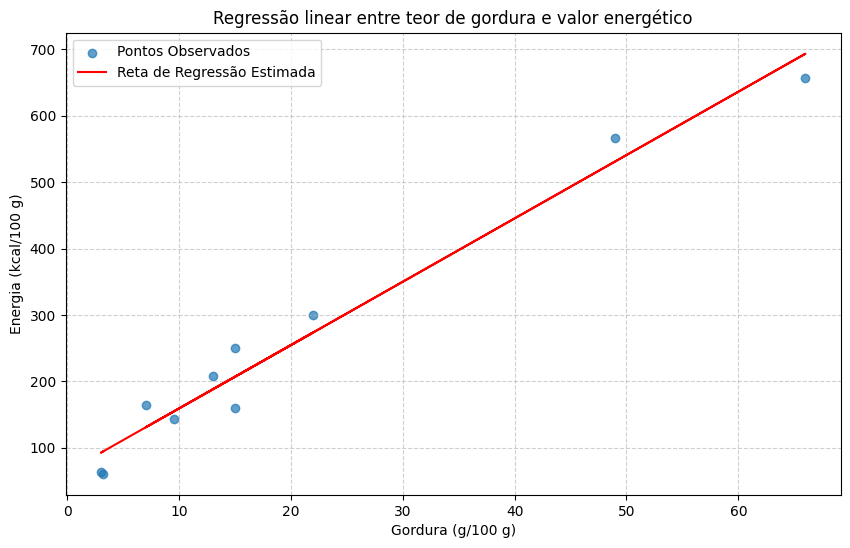

In [9]:
# Reconstruct the scatter plot with the regression line
plt.figure(figsize=(10, 6))

# Plot observed points
plt.scatter(df['Gordura (g/100 g)'], df['Energia (kcal/100 g)'], alpha=0.7, label='Pontos Observados')

# Plot the regression line
# Generate predicted Y values using the model
plt.plot(X, model.predict(X), color='red', linestyle='-', label='Reta de Regressão Estimada')

# Add title and labels
plt.title('Regressão linear entre teor de gordura e valor energético')
plt.xlabel('Gordura (g/100 g)')
plt.ylabel('Energia (kcal/100 g)')

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend
plt.legend()

# Show the plot
plt.show()


### O que é a Correlação Linear de Pearson?

A correlação linear de Pearson é uma medida estatística que nos diz o quão forte e em que direção duas variáveis numéricas se relacionam linearmente. Pense nela como uma forma de quantificar se, por exemplo, à medida que uma coisa aumenta, a outra também tende a aumentar de forma consistente, ou se uma tende a diminuir quando a outra aumenta.

Seu valor varia entre **-1 e +1**:

*   **+1:** Significa uma correlação positiva perfeita. Se uma variável aumenta, a outra aumenta na mesma proporção de forma exata.
*   **-1:** Significa uma correlação negativa perfeita. Se uma variável aumenta, a outra diminui na mesma proporção de forma exata.
*   **0:** Significa que não há relação linear entre as variáveis. Mudanças em uma não estão linearmente associadas a mudanças na outra.

O **sinal** do coeficiente indica a **direção** da relação:
*   **Positivo (+):** Indica que as variáveis se movem na mesma direção. Quando uma aumenta, a outra tende a aumentar.
*   **Negativo (-):** Indica que as variáveis se movem em direções opostas. Quando uma aumenta, a outra tende a diminuir.

Já a **magnitude** (o valor absoluto) indica a **força** da relação:
*   Valores próximos de 1 (seja positivo ou negativo) indicam uma relação forte.
*   Valores próximos de 0 indicam uma relação fraca.

In [11]:
# Calculate Pearson's correlation coefficient
correlation_coefficient = df['Gordura (g/100 g)'].corr(df['Energia (kcal/100 g)'])

print(f"Coeficiente de Correlação de Pearson: {correlation_coefficient:.2f}")


Coeficiente de Correlação de Pearson: 0.98


### Interpretação da Correlação de Pearson

Com base no coeficiente de correlação de Pearson calculado, que é de **0.98**:

*   **Direção:** O sinal positivo indica que existe uma **relação linear positiva** entre o teor de gordura e o valor energético dos alimentos. Isso significa que, em geral, alimentos com maior teor de gordura tendem a ter um valor energético mais alto, e vice-versa.

*   **Força:** Um valor de 0.98 é considerado **muito forte**. Isso sugere que a relação linear entre o teor de gordura e o valor energético é muito consistente e previsível. Em outras palavras, a gordura é um excelente indicador para prever o valor energético de um alimento, dentro dos dados que analisamos.

Essa correlação muito forte e positiva corrobora o que observamos no gráfico de dispersão e na reta de regressão, onde os pontos tendem a se agrupar extremamente próximos à linha ascendente.

### Correlação Zero ou Próxima de Zero

 Correlação de Pearson **igual ou muito próximo de zero** indica que há **ausência ou uma baixa intensidade de relação *linear*** entre as variáveis. Ou seja, não há uma tendência clara para uma variável aumentar ou diminuir de forma *proporcional* quando a outra muda.

No entanto, isso **NÃO significa necessariamente que não existe *nenhuma* relação entre elas**! Pode ser que exista uma **relação não linear** muito forte. Por exemplo, a relação entre duas variáveis pode ser parabólica (formando uma curva 'U' ou '∩'). Nesses casos, o coeficiente de Pearson pode ser próximo de zero porque ele só mede relações *lineares*, mas visualmente no gráfico de dispersão veríamos uma clara associação, mesmo que não seja uma linha reta. Então, sempre olhe para o gráfico de dispersão!

### Fórmulas Utilizadas

#### 1. Fórmula da Regressão Linear Simples

A equação estimada da reta de regressão linear simples é dada por:

$$\hat{Y} = b_0 + b_1X$$

Onde:
*   $\hat{Y}$: É o valor **previsto** ou **estimado** da variável dependente (neste caso, Energia).
*   $b_0$: É o **intercepto** (ou constante), representando o valor de $\hat{Y}$ quando $X$ é zero.
*   $b_1$: É o **coeficiente angular** (ou inclinação), indicando a variação em $\hat{Y}$ para cada unidade de mudança em $X$.
*   $X$: É a variável independente (neste caso, Gordura).

#### 2. Fórmulas dos Coeficientes $b_0$ e $b_1$

Os coeficientes $b_0$ e $b_1$ são calculados para minimizar a soma dos quadrados dos resíduos (a distância vertical dos pontos até a linha de regressão).

**Coeficiente Angular ($b_1$):**

$$b_1 = \frac{n\sum(XY) - \sum X \sum Y}{n\sum(X^2) - (\sum X)^2}$$

Onde:
*   $n$: É o número de observações (pares de dados).
*   $\sum(XY)$: É a soma dos produtos de $X$ e $Y$.
*   $\sum X$: É a soma de todos os valores de $X$.
*   $\sum Y$: É a soma de todos os valores de $Y$.
*   $\sum(X^2)$: É a soma dos quadrados de todos os valores de $X$.

**Intercepto ($b_0$):**

$$b_0 = \bar{Y} - b_1\bar{X}$$

Onde:
*   $\bar{Y}$: É a média dos valores de $Y$.
*   $\bar{X}$: É a média dos valores de $X$.
*   $b_1$: É o coeficiente angular calculado anteriormente.

#### 3. Fórmula do Coeficiente de Correlação Linear de Pearson ($r$)

O coeficiente de correlação de Pearson, também conhecido como $r$, é calculado como:

$$r = \frac{n\sum(XY) - \sum X \sum Y}{\sqrt{\left[n\sum(X^2) - (\sum X)^2\right]\left[n\sum(Y^2) - (\sum Y)^2\right]}}$$

Onde:
*   $n$: É o número de observações.
*   $\sum(XY)$: É a soma dos produtos de $X$ e $Y$.
*   $\sum X$: É a soma de todos os valores de $X$.
*   $\sum Y$: É a soma de todos os valores de $Y$.
*   $\sum(X^2)$: É a soma dos quadrados de todos os valores de $X$.
*   $\sum(Y^2)$: É a soma dos quadrados de todos os valores de $Y$.

Alternativamente, o coeficiente de Pearson pode ser expresso em termos de covariância e desvios padrão:

$$r = \frac{Cov(X,Y)}{s_X s_Y}$$

Onde:
*   $Cov(X,Y)$: É a covariância entre $X$ e $Y$.
*   $s_X$: É o desvio padrão de $X$.
*   $s_Y$: É o desvio padrão de $Y$.

#Os dados utilizados nesta atividade são fictícios e foram criados com o auxílio de inteligência artificial (IA)